# Documentación técnica del pipeline de Ingeniería de Datos

**Dominios:** Billing, CRM y University  
**Arquitectura:** CSV Raw → Bronze Parquet → Silver Parquet → Gold PostgreSQL → Dashboard  
**Estado documentado:** ingesta, profiling, Bronze y Silver completados; Gold pendiente.

Este notebook funciona como evidencia técnica ejecutable del proceso realizado. El código productivo permanece en `src/`; aquí se muestran controles, resultados, decisiones y hallazgos relevantes para la presentación.

## Cómo ejecutar el notebook

Ejecutar Jupyter desde la raíz del repositorio:

```bash
python -m jupyter lab
```

Luego abrir `notebooks/01_pipeline_documentation.ipynb` y ejecutar las celdas en orden.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

current_path = Path.cwd().resolve()
PROJECT_ROOT = current_path.parent if current_path.name == "notebooks" else current_path

RAW_ROOT = PROJECT_ROOT / "data" / "raw"
BRONZE_ROOT = PROJECT_ROOT / "data" / "bronze"
SILVER_ROOT = PROJECT_ROOT / "data" / "silver"

for required_path in (RAW_ROOT, BRONZE_ROOT, SILVER_ROOT):
    if not required_path.exists():
        raise FileNotFoundError(f"Required project path not found: {required_path}")

print(f"Project root: {PROJECT_ROOT}")

Project root: E:\DataTech\data-eng\gotech-data-engineering-tigo


## 1. Objetivo y problema

El proyecto parte de datos crudos de tres sistemas que representan una institución que ofrece cursos, gestiona relaciones comerciales y factura productos o suscripciones.

El objetivo es construir un pipeline reproducible que:

1. preserve los datos originales;
2. detecte y trate problemas de calidad;
3. aplique tipado y reglas de integridad;
4. modele información analítica orientada al negocio;
5. produzca KPIs, insights y un dashboard defendible ante una audiencia técnica y ejecutiva.

## 2. Arquitectura seleccionada

```text
CSV Raw
   ↓
Discovery y data profiling
   ↓
Bronze en Parquet
   ↓
Silver en Parquet
   ↓
Gold en PostgreSQL
   ↓
Notebook, Power BI e insights
```

**Justificación resumida**

- **CSV:** formato de entrega de los sistemas fuente.
- **Parquet en Bronze y Silver:** formato columnar, tipado, compresión y lectura eficiente.
- **Python y pandas:** automatización de la ingesta, transformación y validación.
- **PostgreSQL en Gold:** consultas SQL, modelo relacional y conexión sencilla con Power BI.
- **Airflow:** orquestación e idempotencia del pipeline completo.
- **Docker:** ambiente reproducible.
- **Git:** trazabilidad del proceso y de las decisiones técnicas.

## 3. Inventario de fuentes

In [2]:
def build_file_inventory(raw_root: Path) -> pd.DataFrame:
    records = []

    for csv_path in sorted(raw_root.rglob("*.csv")):
        dataframe = pd.read_csv(csv_path)
        records.append(
            {
                "domain": csv_path.parent.name,
                "table": csv_path.stem,
                "rows": len(dataframe),
                "columns": len(dataframe.columns),
                "size_mb": csv_path.stat().st_size / (1024 ** 2),
            }
        )

    return pd.DataFrame(records)

raw_inventory = build_file_inventory(RAW_ROOT)
display(raw_inventory)

print(f"Domains: {raw_inventory['domain'].nunique()}")
print(f"CSV files: {len(raw_inventory)}")
print(f"Total rows across sources: {raw_inventory['rows'].sum():,}")

,domain,table,rows,columns,size_mb
0,billing,customers,10000,8,0.89
1,billing,invoice_items,150000,6,7.66
2,billing,invoices,50000,7,3.02
3,billing,payments,80000,5,3.89
4,billing,products,200,6,0.01
5,billing,subscriptions,15000,6,0.91
6,crm,accounts,5000,7,0.33
7,crm,activities,20000,6,1.37
8,crm,contacts,15000,8,1.61
9,crm,leads,2000,8,0.18


Domains: 3
CSV files: 18
Total rows across sources: 446,708


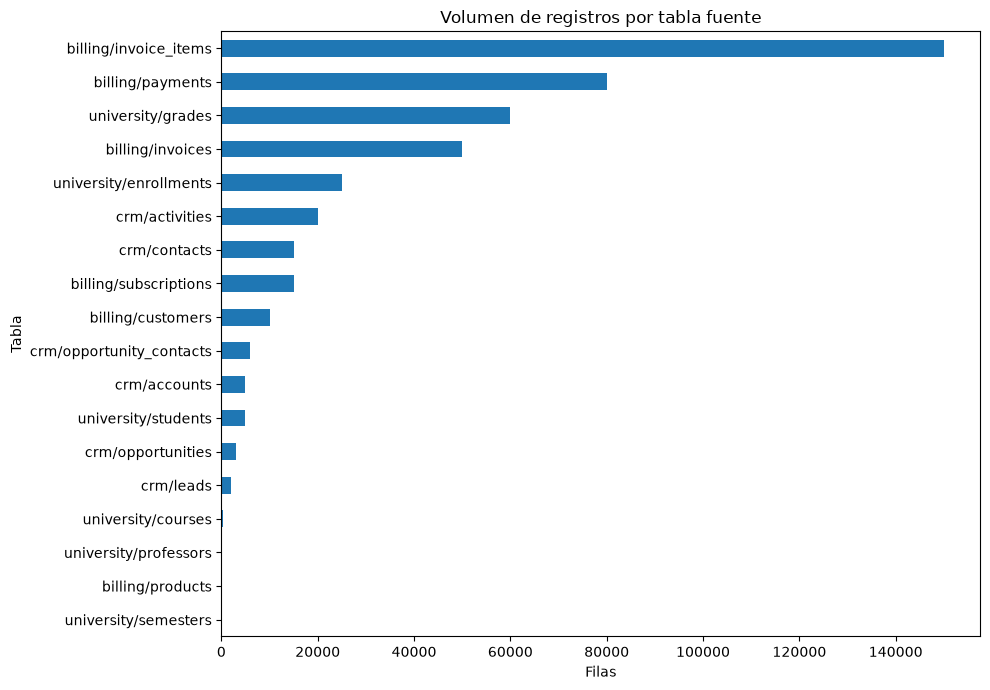

In [3]:
rows_by_table = (
    raw_inventory
    .assign(table_name=lambda df: df["domain"] + "/" + df["table"])
    .sort_values("rows")
)

ax = rows_by_table.plot(
    x="table_name",
    y="rows",
    kind="barh",
    figsize=(10, 7),
    legend=False,
)
ax.set_title("Volumen de registros por tabla fuente")
ax.set_xlabel("Filas")
ax.set_ylabel("Tabla")
plt.tight_layout()
plt.show()

Los datos se distribuyen en 18 archivos:

- **Billing:** clientes, productos, suscripciones, facturas, líneas y pagos.
- **CRM:** cuentas, contactos, leads, oportunidades, relaciones y actividades.
- **University:** estudiantes, profesores, cursos, semestres, inscripciones y calificaciones.

## 4. Data profiling inicial

In [4]:
def profile_csv_files(raw_root: Path) -> pd.DataFrame:
    records = []

    for csv_path in sorted(raw_root.rglob("*.csv")):
        dataframe = pd.read_csv(csv_path)
        records.append(
            {
                "domain": csv_path.parent.name,
                "table": csv_path.stem,
                "rows": len(dataframe),
                "columns": len(dataframe.columns),
                "null_cells": int(dataframe.isna().sum().sum()),
                "duplicate_rows": int(dataframe.duplicated().sum()),
                "numeric_columns": len(dataframe.select_dtypes(include="number").columns),
                "text_columns": len(dataframe.select_dtypes(include="object").columns),
            }
        )

    return pd.DataFrame(records)

profiling_summary = profile_csv_files(RAW_ROOT)
display(profiling_summary)

C:\Users\sebas\AppData\Local\Temp\ipykernel_16812\1076358795.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  "text_columns": len(dataframe.select_dtypes(include="object").columns),
C:\Users\sebas\AppData\Local\Temp\ipykernel_16812\1076358795.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.o

,domain,table,rows,columns,null_cells,duplicate_rows,numeric_columns,text_columns
0,billing,customers,10000,8,5000,0,0,8
1,billing,invoice_items,150000,6,0,0,3,3
2,billing,invoices,50000,7,0,0,1,6
3,billing,payments,80000,5,0,0,1,4
4,billing,products,200,6,0,0,1,4
5,billing,subscriptions,15000,6,0,0,0,6
6,crm,accounts,5000,7,0,0,2,5
7,crm,activities,20000,6,15961,0,0,6
8,crm,contacts,15000,8,0,0,0,8
9,crm,leads,2000,8,0,0,1,7


In [5]:
quality_overview = profiling_summary.loc[
    (profiling_summary["null_cells"] > 0)
    | (profiling_summary["duplicate_rows"] > 0)
]

display(quality_overview)

,domain,table,rows,columns,null_cells,duplicate_rows,numeric_columns,text_columns
0,billing,customers,10000,8,5000,0,0,8
7,crm,activities,20000,6,15961,0,0,6


El profiling inicial permite identificar volúmenes, tipos inferidos, nulos y duplicados completos. Estas observaciones no se corrigen todavía en Raw ni Bronze: primero se preserva la fuente y posteriormente se aplican reglas explícitas en Silver.

## 5. Construcción y validación de Bronze

Bronze conserva la estructura original y cambia el formato físico de CSV a Parquet. La organización por dominio se mantiene para facilitar trazabilidad:

```text
data/bronze/
├── billing/
├── crm/
└── university/
```

La validación mínima verifica que cada CSV tenga un Parquet correspondiente con la misma cantidad de filas y columnas.

In [6]:
def reconcile_raw_to_bronze(
    raw_root: Path,
    bronze_root: Path,
) -> pd.DataFrame:
    records = []

    for csv_path in sorted(raw_root.rglob("*.csv")):
        relative_path = csv_path.relative_to(raw_root)
        parquet_path = (bronze_root / relative_path).with_suffix(".parquet")

        raw_dataframe = pd.read_csv(csv_path)
        bronze_dataframe = pd.read_parquet(parquet_path)

        records.append(
            {
                "table": str(relative_path.with_suffix("")),
                "raw_rows": len(raw_dataframe),
                "bronze_rows": len(bronze_dataframe),
                "raw_columns": len(raw_dataframe.columns),
                "bronze_columns": len(bronze_dataframe.columns),
                "is_valid": raw_dataframe.shape == bronze_dataframe.shape,
            }
        )

    return pd.DataFrame(records)

raw_bronze_reconciliation = reconcile_raw_to_bronze(RAW_ROOT, BRONZE_ROOT)
display(raw_bronze_reconciliation)
assert raw_bronze_reconciliation["is_valid"].all()

,table,raw_rows,bronze_rows,raw_columns,bronze_columns,is_valid
0,billing\customers,10000,10000,8,8,True
1,billing\invoice_items,150000,150000,6,6,True
2,billing\invoices,50000,50000,7,7,True
3,billing\payments,80000,80000,5,5,True
4,billing\products,200,200,6,6,True
5,billing\subscriptions,15000,15000,6,6,True
6,crm\accounts,5000,5000,7,7,True
7,crm\activities,20000,20000,6,6,True
8,crm\contacts,15000,15000,8,8,True
9,crm\leads,2000,2000,8,8,True


## 6. Construcción de Silver

Silver aplica reglas técnicas y de calidad:

- conversión explícita de fechas;
- validación de claves primarias y foráneas;
- rangos numéricos;
- categorías permitidas;
- reglas cronológicas;
- conservación de conteos;
- banderas para atributos de fuente inconsistentes.

Las filas no se eliminan silenciosamente. Cuando una fecha de negocio es inválida, se conserva el registro, se anula únicamente el atributo defectuoso y se añade una bandera de calidad.

In [7]:
def reconcile_bronze_to_silver(
    bronze_root: Path,
    silver_root: Path,
) -> pd.DataFrame:
    records = []

    for bronze_path in sorted(bronze_root.rglob("*.parquet")):
        relative_path = bronze_path.relative_to(bronze_root)
        silver_path = silver_root / relative_path

        bronze_dataframe = pd.read_parquet(bronze_path)
        silver_dataframe = pd.read_parquet(silver_path)

        records.append(
            {
                "table": str(relative_path.with_suffix("")),
                "bronze_rows": len(bronze_dataframe),
                "silver_rows": len(silver_dataframe),
                "is_valid": len(bronze_dataframe) == len(silver_dataframe),
            }
        )

    return pd.DataFrame(records)

bronze_silver_reconciliation = reconcile_bronze_to_silver(
    BRONZE_ROOT,
    SILVER_ROOT,
)
display(bronze_silver_reconciliation)
assert bronze_silver_reconciliation["is_valid"].all()

,table,bronze_rows,silver_rows,is_valid
0,billing\customers,10000,10000,True
1,billing\invoice_items,150000,150000,True
2,billing\invoices,50000,50000,True
3,billing\payments,80000,80000,True
4,billing\products,200,200,True
5,billing\subscriptions,15000,15000,True
6,crm\accounts,5000,5000,True
7,crm\activities,20000,20000,True
8,crm\contacts,15000,15000,True
9,crm\leads,2000,2000,True


### 6.1. Validación del parsing de fechas originales

In [8]:
DATE_COLUMNS_BY_FILE = {
    "customers": ["created_at"],
    "invoices": ["issued_at", "due_at"],
    "payments": ["paid_at"],
    "subscriptions": ["start_date", "end_date"],
    "accounts": ["created_at"],
    "activities": ["occurred_at"],
    "contacts": ["created_at"],
    "leads": ["created_at"],
    "opportunities": ["close_date", "created_at"],
    "enrollments": ["enrolled_at"],
    "grades": ["graded_at"],
    "professors": ["hired_at"],
    "semesters": ["start_date", "end_date"],
    "students": ["birth_date", "enrolled_at"],
}

records = []
for bronze_path in sorted(BRONZE_ROOT.rglob("*.parquet")):
    date_columns = DATE_COLUMNS_BY_FILE.get(bronze_path.stem, [])
    dataframe = pd.read_parquet(bronze_path)

    for column in date_columns:
        parsed_values = pd.to_datetime(dataframe[column], errors="coerce")
        invalid_rows = int((dataframe[column].notna() & parsed_values.isna()).sum())
        records.append(
            {
                "table": bronze_path.stem,
                "column": column,
                "invalid_rows": invalid_rows,
                "is_valid": invalid_rows == 0,
            }
        )

date_parsing_validation = pd.DataFrame(records)
display(date_parsing_validation)
assert date_parsing_validation["is_valid"].all()

,table,column,invalid_rows,is_valid
0,customers,created_at,0,True
1,invoices,issued_at,0,True
2,invoices,due_at,0,True
3,payments,paid_at,0,True
4,subscriptions,start_date,0,True
5,subscriptions,end_date,0,True
6,accounts,created_at,0,True
7,activities,occurred_at,0,True
8,contacts,created_at,0,True
9,leads,created_at,0,True


No existen errores de formato en las fechas originales. Las inconsistencias encontradas son de lógica de negocio: la fecha puede interpretarse, pero su orden cronológico es imposible.

### 6.2. Fechas cronológicamente inconsistentes y tratamiento

In [9]:
bronze_subscriptions = pd.read_parquet(
    BRONZE_ROOT / "billing" / "subscriptions.parquet"
)
bronze_opportunities = pd.read_parquet(
    BRONZE_ROOT / "crm" / "opportunities.parquet"
)
silver_subscriptions = pd.read_parquet(
    SILVER_ROOT / "billing" / "subscriptions.parquet"
)
silver_opportunities = pd.read_parquet(
    SILVER_ROOT / "crm" / "opportunities.parquet"
)

subscription_start = pd.to_datetime(bronze_subscriptions["start_date"])
subscription_end = pd.to_datetime(bronze_subscriptions["end_date"])
opportunity_created = pd.to_datetime(bronze_opportunities["created_at"])
opportunity_close = pd.to_datetime(bronze_opportunities["close_date"])

chronological_findings = pd.DataFrame(
    [
        {
            "rule": "subscriptions.end_date >= start_date",
            "source_invalid_rows": int(
                (subscription_end.notna() & (subscription_end < subscription_start)).sum()
            ),
            "silver_invalid_rows": int(
                (
                    silver_subscriptions["end_date"].notna()
                    & (
                        silver_subscriptions["end_date"]
                        < silver_subscriptions["start_date"]
                    )
                ).sum()
            ),
            "quality_flags_false": int(
                (~silver_subscriptions["end_date_quality_valid"]).sum()
            ),
        },
        {
            "rule": "opportunities.close_date >= created_at",
            "source_invalid_rows": int(
                (opportunity_close.notna() & (opportunity_close < opportunity_created)).sum()
            ),
            "silver_invalid_rows": int(
                (
                    silver_opportunities["close_date"].notna()
                    & (
                        silver_opportunities["close_date"]
                        < silver_opportunities["created_at"]
                    )
                ).sum()
            ),
            "quality_flags_false": int(
                (~silver_opportunities["close_date_quality_valid"]).sum()
            ),
        },
    ]
)

display(chronological_findings)

,rule,source_invalid_rows,silver_invalid_rows,quality_flags_false
0,subscriptions.end_date >= start_date,783,0,783
1,opportunities.close_date >= created_at,1029,0,1029


### 6.3. Integridad de claves primarias

In [10]:
PRIMARY_KEYS_BY_FILE = {
    "customers": ["customer_id"],
    "invoice_items": ["invoice_item_id"],
    "invoices": ["invoice_id"],
    "payments": ["payment_id"],
    "products": ["product_id"],
    "subscriptions": ["subscription_id"],
    "accounts": ["account_id"],
    "activities": ["activity_id"],
    "contacts": ["contact_id"],
    "leads": ["lead_id"],
    "opportunities": ["opportunity_id"],
    "opportunity_contacts": ["opportunity_id", "contact_id"],
    "courses": ["course_id"],
    "enrollments": ["enrollment_id"],
    "grades": ["grade_id"],
    "professors": ["professor_id"],
    "semesters": ["semester_id"],
    "students": ["student_id"],
}

records = []
for silver_path in sorted(SILVER_ROOT.rglob("*.parquet")):
    dataframe = pd.read_parquet(silver_path)
    key_columns = PRIMARY_KEYS_BY_FILE[silver_path.stem]
    null_rows = int(dataframe[key_columns].isna().any(axis=1).sum())
    duplicate_rows = int(dataframe.duplicated(subset=key_columns).sum())
    records.append(
        {
            "table": silver_path.stem,
            "key": ", ".join(key_columns),
            "null_rows": null_rows,
            "duplicate_rows": duplicate_rows,
            "is_valid": null_rows == 0 and duplicate_rows == 0,
        }
    )

primary_key_validation = pd.DataFrame(records)
display(primary_key_validation)
assert primary_key_validation["is_valid"].all()

,table,key,null_rows,duplicate_rows,is_valid
0,customers,customer_id,0,0,True
1,invoice_items,invoice_item_id,0,0,True
2,invoices,invoice_id,0,0,True
3,payments,payment_id,0,0,True
4,products,product_id,0,0,True
5,subscriptions,subscription_id,0,0,True
6,accounts,account_id,0,0,True
7,activities,activity_id,0,0,True
8,contacts,contact_id,0,0,True
9,leads,lead_id,0,0,True


### 6.4. Integridad referencial

In [11]:
FOREIGN_KEYS = [
    ("billing/invoices", "customer_id", "billing/customers", "customer_id", False),
    ("billing/invoice_items", "invoice_id", "billing/invoices", "invoice_id", False),
    ("billing/invoice_items", "product_id", "billing/products", "product_id", False),
    ("billing/payments", "invoice_id", "billing/invoices", "invoice_id", False),
    ("billing/subscriptions", "customer_id", "billing/customers", "customer_id", False),
    ("billing/subscriptions", "product_id", "billing/products", "product_id", False),
    ("crm/activities", "contact_id", "crm/contacts", "contact_id", True),
    ("crm/activities", "opportunity_id", "crm/opportunities", "opportunity_id", True),
    ("crm/contacts", "account_id", "crm/accounts", "account_id", False),
    ("crm/opportunities", "account_id", "crm/accounts", "account_id", False),
    ("crm/opportunity_contacts", "opportunity_id", "crm/opportunities", "opportunity_id", False),
    ("crm/opportunity_contacts", "contact_id", "crm/contacts", "contact_id", False),
    ("university/courses", "professor_id", "university/professors", "professor_id", False),
    ("university/enrollments", "student_id", "university/students", "student_id", False),
    ("university/enrollments", "course_id", "university/courses", "course_id", False),
    ("university/enrollments", "semester_id", "university/semesters", "semester_id", False),
    ("university/grades", "enrollment_id", "university/enrollments", "enrollment_id", False),
]

records = []
for child_table, child_key, parent_table, parent_key, nullable in FOREIGN_KEYS:
    child = pd.read_parquet(SILVER_ROOT / f"{child_table}.parquet")
    parent = pd.read_parquet(SILVER_ROOT / f"{parent_table}.parquet")

    values = child[child_key]
    values_to_validate = values.dropna() if nullable else values
    orphan_rows = int((~values_to_validate.isin(parent[parent_key])).sum())

    records.append(
        {
            "relationship": f"{child_table}.{child_key} → {parent_table}.{parent_key}",
            "orphan_rows": orphan_rows,
            "is_valid": orphan_rows == 0,
        }
    )

foreign_key_validation = pd.DataFrame(records)
display(foreign_key_validation)
assert foreign_key_validation["is_valid"].all()

,relationship,orphan_rows,is_valid
0,billing/invoices.customer_id → billing/customers.customer_id,0,True
1,billing/invoice_items.invoice_id → billing/invoices.invoice_id,0,True
2,billing/invoice_items.product_id → billing/products.product_id,0,True
3,billing/payments.invoice_id → billing/invoices.invoice_id,0,True
4,billing/subscriptions.customer_id → billing/customers.customer_id,0,True
5,billing/subscriptions.product_id → billing/products.product_id,0,True
6,crm/activities.contact_id → crm/contacts.contact_id,0,True
7,crm/activities.opportunity_id → crm/opportunities.opportunity_id,0,True
8,crm/contacts.account_id → crm/accounts.account_id,0,True
9,crm/opportunities.account_id → crm/accounts.account_id,0,True


### 6.5. Cálculo de líneas de factura

In [12]:
invoice_items = pd.read_parquet(
    SILVER_ROOT / "billing" / "invoice_items.parquet"
)

expected_line_total = invoice_items["quantity"] * invoice_items["unit_price"]
line_differences = (invoice_items["line_total"] - expected_line_total).abs()

invoice_line_validation = pd.DataFrame(
    [
        {
            "rows_checked": len(invoice_items),
            "invalid_rows_tolerance_0_01": int((line_differences > 0.01).sum()),
            "maximum_difference": float(line_differences.max()),
        }
    ]
)
display(invoice_line_validation)

,rows_checked,invalid_rows_tolerance_0_01,maximum_difference
0,150000,0,0.00


La diferencia máxima es microscópica y se debe a la representación binaria de números decimales en punto flotante. No constituye una inconsistencia de negocio.

## 7. Advertencias no bloqueantes

### 7.1. Pesos de calificaciones

In [13]:
grades = pd.read_parquet(
    SILVER_ROOT / "university" / "grades.parquet"
)

weight_totals = grades.groupby("enrollment_id")["weight"].sum()
weight_differences = (weight_totals - 1.0).abs()

grade_weight_finding = pd.DataFrame(
    [
        {
            "enrollments_checked": len(weight_totals),
            "invalid_enrollments_tolerance_0_01": int(
                (weight_differences > 0.01).sum()
            ),
            "minimum_weight_sum": float(weight_totals.min()),
            "maximum_weight_sum": float(weight_totals.max()),
        }
    ]
)
display(grade_weight_finding)

,enrollments_checked,invalid_enrollments_tolerance_0_01,minimum_weight_sum,maximum_weight_sum
0,22786,22645,0.10,3.31


Los pesos se preservan en Silver. Para Gold se evaluará una nota normalizada por inscripción:

```text
SUM(score × weight) / SUM(weight)
```

La normalización será una regla analítica explícita, no una alteración silenciosa de los datos originales.

### 7.2. Correos repetidos en contactos CRM

In [14]:
contacts = pd.read_parquet(
    SILVER_ROOT / "crm" / "contacts.parquet"
)

duplicate_email_contacts = contacts.loc[
    contacts["email"].notna()
    & contacts.duplicated(subset=["email"], keep=False),
    ["contact_id", "email", "account_id", "phone", "title"],
].sort_values("email")

display(duplicate_email_contacts)
print(f"Affected records: {len(duplicate_email_contacts)}")
print(f"Repeated email addresses: {duplicate_email_contacts['email'].nunique()}")

,contact_id,email,account_id,phone,title
2466,CON-0002467,ignacio.tapia5946@mail.test,ACC-0002715,+56 2 1734 8337,Sales Rep
8391,CON-0008392,ignacio.tapia5946@mail.test,ACC-0004626,+56 4 4757 9123,Sales Rep
3103,CON-0003104,macarena.ortiz4996@lake.local,ACC-0003066,+56 7 6270 2411,VP
4934,CON-0004935,macarena.ortiz4996@lake.local,ACC-0001325,+56 3 5450 9335,Analyst


Affected records: 4
Repeated email addresses: 2


Estos registros no son duplicados completos y no se eliminan. El correo se considera un atributo descriptivo con posibles colisiones, no una clave primaria confiable.

## 8. Hallazgos de reconciliación financiera

### 8.1. Facturas frente a líneas

In [15]:
invoices = pd.read_parquet(
    SILVER_ROOT / "billing" / "invoices.parquet"
)
invoice_items = pd.read_parquet(
    SILVER_ROOT / "billing" / "invoice_items.parquet"
)

item_totals = (
    invoice_items.groupby("invoice_id", as_index=False)["line_total"]
    .sum()
    .rename(columns={"line_total": "item_total"})
)

invoice_reconciliation = invoices.merge(
    item_totals,
    on="invoice_id",
    how="left",
)
invoice_reconciliation["has_items"] = invoice_reconciliation["item_total"].notna()
invoice_reconciliation["item_total"] = invoice_reconciliation["item_total"].fillna(0)
invoice_reconciliation["difference"] = (
    invoice_reconciliation["total"]
    - invoice_reconciliation["item_total"]
)

invoice_item_summary = pd.DataFrame(
    [
        {
            "invoices": len(invoice_reconciliation),
            "invoices_without_items": int((~invoice_reconciliation["has_items"]).sum()),
            "mismatches_over_0_01": int(
                (invoice_reconciliation["difference"].abs() > 0.01).sum()
            ),
            "matches_within_0_01": int(
                (invoice_reconciliation["difference"].abs() <= 0.01).sum()
            ),
        }
    ]
)
display(invoice_item_summary)

,invoices,invoices_without_items,mismatches_over_0_01,matches_within_0_01
0,50000,2502,49999,1


Decisión: usar `invoices.total` para KPIs de facturación de cabecera y `invoice_items.line_total` para análisis de productos. Las fuentes no deben mezclarse sin identificar la métrica utilizada.

### 8.2. Facturas frente a pagos

In [16]:
payments = pd.read_parquet(
    SILVER_ROOT / "billing" / "payments.parquet"
)

payment_totals = (
    payments.groupby("invoice_id", as_index=False)["amount"]
    .sum()
    .rename(columns={"amount": "paid_total"})
)

payment_reconciliation = invoices.merge(
    payment_totals,
    on="invoice_id",
    how="left",
)
payment_reconciliation["has_payments"] = payment_reconciliation["paid_total"].notna()
payment_reconciliation["paid_total"] = payment_reconciliation["paid_total"].fillna(0)
payment_reconciliation["balance"] = (
    payment_reconciliation["total"]
    - payment_reconciliation["paid_total"]
)

payment_summary = pd.DataFrame(
    [
        {
            "invoices": len(payment_reconciliation),
            "without_payments": int((~payment_reconciliation["has_payments"]).sum()),
            "balanced_within_0_01": int(
                (payment_reconciliation["balance"].abs() <= 0.01).sum()
            ),
            "underpaid": int((payment_reconciliation["balance"] > 0.01).sum()),
            "overpaid": int((payment_reconciliation["balance"] < -0.01).sum()),
        }
    ]
)
display(payment_summary)

,invoices,without_payments,balanced_within_0_01,underpaid,overpaid
0,50000,18567,5,29512,20483


Facturación y pagos se tratarán como métricas separadas. Sin reglas adicionales del sistema fuente, no es correcto interpretar automáticamente cada diferencia como deuda, error o crédito.

## 9. Relación entre Billing y University

In [17]:
customers = pd.read_parquet(
    SILVER_ROOT / "billing" / "customers.parquet"
)
students = pd.read_parquet(
    SILVER_ROOT / "university" / "students.parquet"
)

customer_refs = customers["external_ref"].astype("string")
student_ids = students["student_id"].astype("string")

cross_domain_summary = pd.DataFrame(
    [
        {
            "customers": len(customers),
            "customers_with_external_ref": int(customers["external_ref"].notna().sum()),
            "customer_refs_matching_students": int(customer_refs.isin(student_ids).sum()),
            "students": len(students),
            "students_matching_customers": int(student_ids.isin(customer_refs).sum()),
        }
    ]
)
display(cross_domain_summary)

,customers,customers_with_external_ref,customer_refs_matching_students,students,students_matching_customers
0,10000,5000,5000,5000,5000


La relación confiable es:

```text
billing.customers.external_ref = university.students.student_id
```

Esta clave conecta los 5.000 estudiantes con 5.000 clientes y permitirá analizar conjuntamente desempeño académico, inscripciones, suscripciones, facturas y pagos.

CRM se mantendrá inicialmente como un mart comercial separado porque no existe una clave compartida suficientemente sólida con los otros dominios.

## 10. Decisiones técnicas y aprendizaje

Principales decisiones aplicadas hasta Silver:

- preservar Raw sin modificaciones;
- convertir Bronze a Parquet conservando estructura y conteos;
- aplicar tipado y reglas explícitas en Silver;
- no eliminar silenciosamente registros con atributos defectuosos;
- diferenciar validaciones bloqueantes de advertencias de fuente;
- no forzar relaciones entre dominios basadas en coincidencias débiles;
- documentar limitaciones antes de construir KPIs.

Este enfoque mejora trazabilidad, reproducibilidad y capacidad de defensa técnica durante la presentación.

## 11. Estado del proyecto y próximos pasos

In [18]:
project_status = pd.DataFrame(
    [
        ("Discovery y profiling", "Completado"),
        ("Bronze Parquet", "Completado"),
        ("Silver Parquet", "Completado y validado"),
        ("Documentación de calidad", "Completado"),
        ("Diseño Gold", "Siguiente paso"),
        ("Gold PostgreSQL", "Pendiente"),
        ("Docker Compose", "Pendiente"),
        ("Airflow", "Pendiente"),
        ("Análisis Gold", "Pendiente"),
        ("Power BI", "Pendiente"),
        ("Presentación", "Pendiente"),
    ],
    columns=["component", "status"],
)
display(project_status)

,component,status
0,Discovery y profiling,Completado
1,Bronze Parquet,Completado
2,Silver Parquet,Completado y validado
3,Documentación de calidad,Completado
4,Diseño Gold,Siguiente paso
5,Gold PostgreSQL,Pendiente
6,Docker Compose,Pendiente
7,Airflow,Pendiente
8,Análisis Gold,Pendiente
9,Power BI,Pendiente


El siguiente paso técnico es definir el grano, las dimensiones, las tablas de hechos y los KPIs de Gold antes de escribir SQL. El modelo se organizará en tres áreas:

1. **Mart académico**.
2. **Mart integrado académico-financiero**.
3. **Mart comercial CRM**.

Una vez aprobado el diseño, Gold se implementará en PostgreSQL y este notebook se complementará con un segundo notebook dedicado a KPIs, gráficos e insights.